In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

print("All libraries loaded successfully!")
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

All libraries loaded successfully!
pandas version: 2.3.3
numpy version: 2.3.5


In [2]:
import urllib.request
import os

url = "https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD"
filename = "ev_population.csv"

print("Downloading EV dataset...")
urllib.request.urlretrieve(url, filename)
print("Download complete!")
print("File size:", os.path.getsize(filename), "bytes")

Download complete!
File size: 67750848 bytes


In [3]:
df = pd.read_csv("ev_population.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Shape: (280833, 16)

Columns: ['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Missing values per column:
VIN (1-10)                                             0
County                                                12
City                                                  12
State                                                  0
Postal Code                                           12
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        12
Legislative District                                 703
DOL Vehicle ID                                         0
Vehicle Location                                      20
Electric Utility                                      12
2020 Census Tract                                     12
dtype: int64

Data types:
VIN (1-10)                         

In [5]:
df_clean = df.dropna(subset=['County', 'City', 'Model Year', 'Make'])

df_clean = df_clean.copy()
df_clean['Electric Range'] = df_clean['Electric Range'].fillna(0)
df_clean['Legislative District'] = df_clean['Legislative District'].fillna(0)

print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Removed:", len(df) - len(df_clean), "rows")
print("\nCleaning complete!")

Original rows: 280833
Clean rows: 280821
Removed: 12 rows

Cleaning complete!


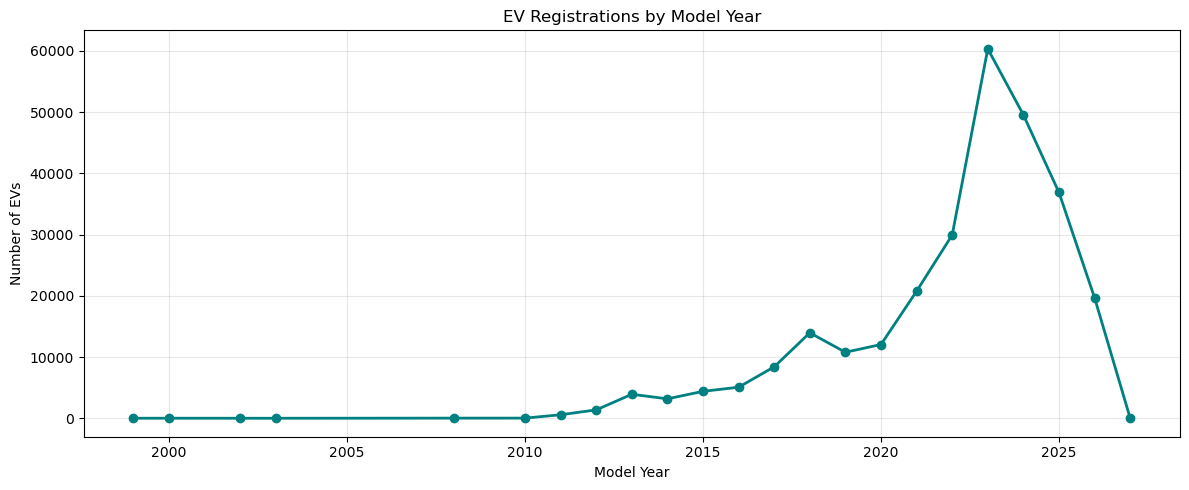

Chart saved!


In [6]:
plt.figure(figsize=(12, 5))

ev_by_year = df_clean.groupby('Model Year').size()

plt.plot(ev_by_year.index, ev_by_year.values, 
         marker='o', color='teal', linewidth=2)

plt.title('EV Registrations by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of EVs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ev_by_year.png')
plt.show()

print("Chart saved!")

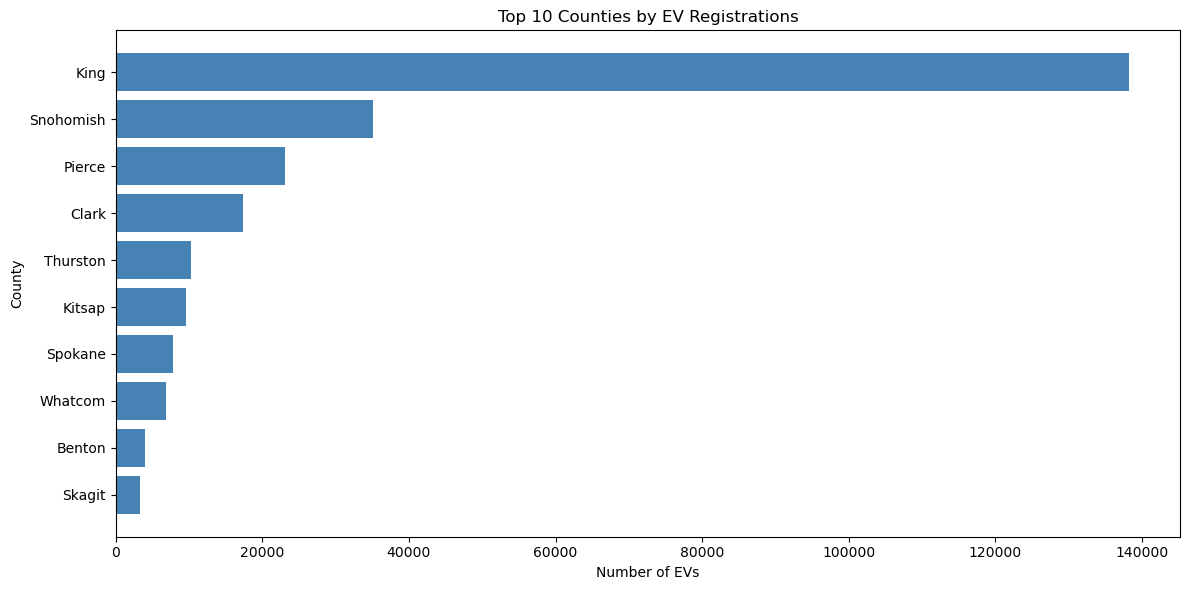

Top counties chart saved!


In [7]:
plt.figure(figsize=(12, 6))

top_counties = df_clean['County'].value_counts().head(10)

plt.barh(top_counties.index, top_counties.values, color='steelblue')
plt.title('Top 10 Counties by EV Registrations')
plt.xlabel('Number of EVs')
plt.ylabel('County')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_counties.png')
plt.show()

print("Top counties chart saved!")

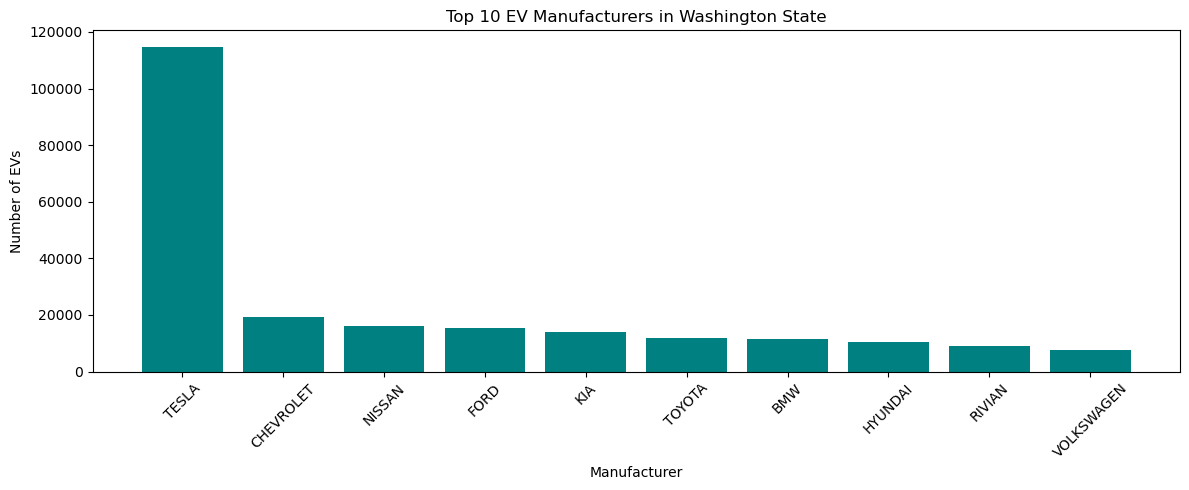

Top makes chart saved!


In [8]:
plt.figure(figsize=(12, 5))

top_makes = df_clean['Make'].value_counts().head(10)

plt.bar(top_makes.index, top_makes.values, color='teal')
plt.title('Top 10 EV Manufacturers in Washington State')
plt.xlabel('Manufacturer')
plt.ylabel('Number of EVs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_makes.png')
plt.show()

print("Top makes chart saved!")

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import numpy as np

yearly = df_clean.groupby('Model Year').size().reset_index()
yearly.columns = ['Year', 'EV_Count']
yearly = yearly[yearly['Year'] >= 2010]

X = yearly[['Year']]
y = yearly['EV_Count']

model = LinearRegression()
model.fit(X, y)

future_years = pd.DataFrame({'Year': [2025, 2026, 2027, 2028]})
predictions = model.predict(future_years)

for year, pred in zip(future_years['Year'], predictions):
    print(f"{year}: {int(pred):,} EVs predicted")

2025: 29,211 EVs predicted
2026: 31,306 EVs predicted
2027: 33,400 EVs predicted
2028: 35,494 EVs predicted


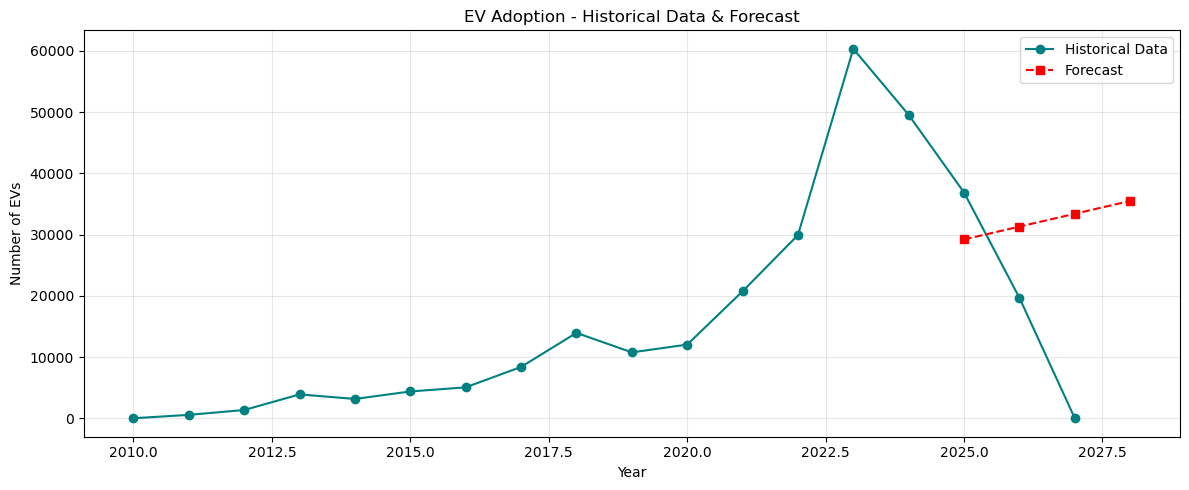

Forecast chart saved!


In [10]:
plt.figure(figsize=(12, 5))

plt.plot(yearly['Year'], yearly['EV_Count'], 
         marker='o', color='teal', label='Historical Data')

plt.plot(future_years['Year'], predictions, 
         marker='s', color='red', linestyle='--', label='Forecast')

plt.title('EV Adoption - Historical Data & Forecast')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast.png')
plt.show()

print("Forecast chart saved!")

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

county_stats = df_clean.groupby('County').agg(
    EV_Count=('Make', 'count'),
    Avg_Range=('Electric Range', 'mean'),
    Avg_Year=('Model Year', 'mean')
).reset_index()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(county_stats[['EV_Count', 'Avg_Range', 'Avg_Year']])

kmeans = KMeans(n_clusters=3, random_state=42)
county_stats['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_names = {0: 'Moderate Adopter', 1: 'Early Adopter', 2: 'Slow Adopter'}
county_stats['Cluster_Name'] = county_stats['Cluster'].map(cluster_names)

for name in ['Early Adopter', 'Moderate Adopter', 'Slow Adopter']:
    counties = county_stats[county_stats['Cluster_Name'] == name]['County'].tolist()
    print(f"\n{name}s: {counties}")


Early Adopters: ['Ada', 'Adams', 'Alexandria', 'Anchorage', 'Arapahoe', 'Asotin', 'Beaufort', 'Benton', 'Burlington', 'Calvert', 'Carroll', 'Chelan', 'Chesapeake', 'Chesterfield', 'Clallam', 'Clark', 'Clay', 'Columbia', 'Cook', 'Coryell', 'Cowlitz', 'Currituck', 'District of Columbia', 'Douglas', 'El Paso', 'Fairfax', 'Ferry', 'Franklin', 'Garfield', 'Grant', 'Grays Harbor', 'Hampton', 'Harris', 'Hennepin', 'Hillsborough', 'Houston', 'Howard', 'Island', 'Jefferson', 'Kern', 'King', 'Kitsap', 'Kittitas', 'Klickitat', 'Kootenai', 'Lewis', 'Lincoln', 'Long', 'Los Angeles', 'Loudoun', 'Madison', 'Manassas', 'Marin', 'Mason', 'Maui', 'Monterey', 'Montgomery', 'New London', 'New York', 'Newport', 'Niagara', 'Okaloosa', 'Okanogan', 'Oldham', 'Onslow', 'Orange', 'Pacific', 'Penobscot', 'Pierce', 'Pinal', 'Platte', 'Polk', 'Portsmouth', "Prince George's", 'Prince William', 'Providence', 'Richland', 'Richmond', 'Riverside', 'Sacramento', 'San Diego', 'San Joaquin', 'San Juan', 'Saratoga', 'Shel

C:\Users\NANOTEK\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


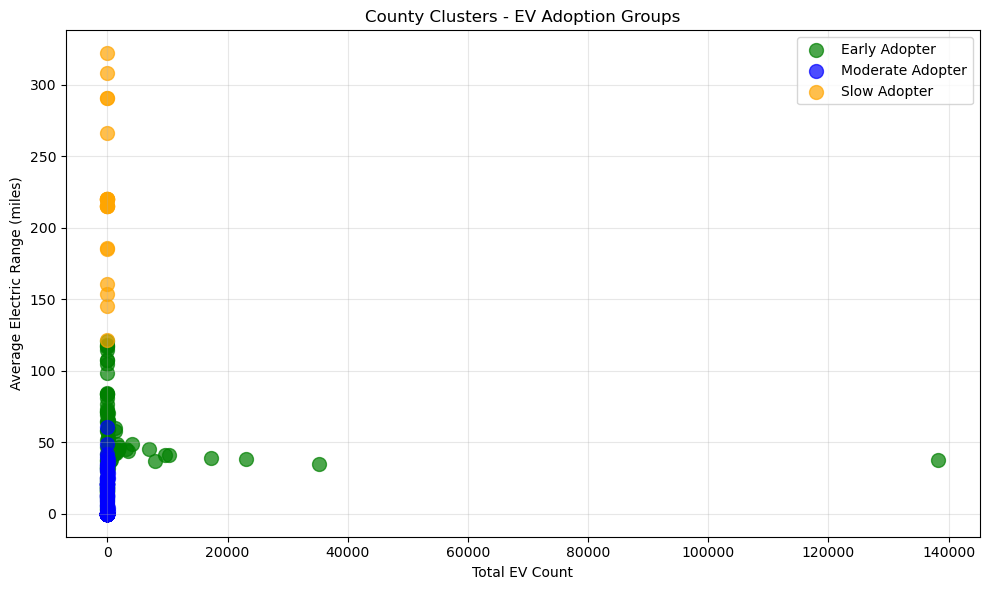

Clustering chart saved!


In [12]:
plt.figure(figsize=(10, 6))

colors = {'Early Adopter': 'green', 
          'Moderate Adopter': 'blue', 
          'Slow Adopter': 'orange'}

for cluster_name, color in colors.items():
    subset = county_stats[county_stats['Cluster_Name'] == cluster_name]
    plt.scatter(subset['EV_Count'], subset['Avg_Range'], 
                label=cluster_name, color=color, alpha=0.7, s=100)

plt.title('County Clusters - EV Adoption Groups')
plt.xlabel('Total EV Count')
plt.ylabel('Average Electric Range (miles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('clustering.png')
plt.show()

print("Clustering chart saved!")

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

yearly = df_clean.groupby('Model Year').size().reset_index()
yearly.columns = ['Year', 'EV_Count']
yearly = yearly[yearly['Year'] >= 2010]

X = yearly[['Year']]
y = yearly['EV_Count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Random Forest Model Results ===")
print(f"MAE  (Mean Absolute Error): {mae:,.0f}")
print(f"RMSE (Root Mean Sq Error):  {rmse:,.0f}")
print("\nRandom Forest trained successfully!")

=== Random Forest Model Results ===
MAE  (Mean Absolute Error): 2,402
RMSE (Root Mean Sq Error):  2,859

Random Forest trained successfully!


In [14]:
lr_pred = model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("=== Model Comparison ===")
print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10}")
print("-" * 42)
print(f"{'Linear Regression':<20} {lr_mae:>10,.0f} {lr_rmse:>10,.0f}")
print(f"{'Random Forest':<20} {mae:>10,.0f} {rmse:>10,.0f}")

better_mae = "Random Forest" if mae < lr_mae else "Linear Regression"
print(f"\nBetter model (lower MAE): {better_mae}")

=== Model Comparison ===
Model                       MAE       RMSE
------------------------------------------
Linear Regression         1,843      2,279
Random Forest             2,402      2,859

Better model (lower MAE): Linear Regression


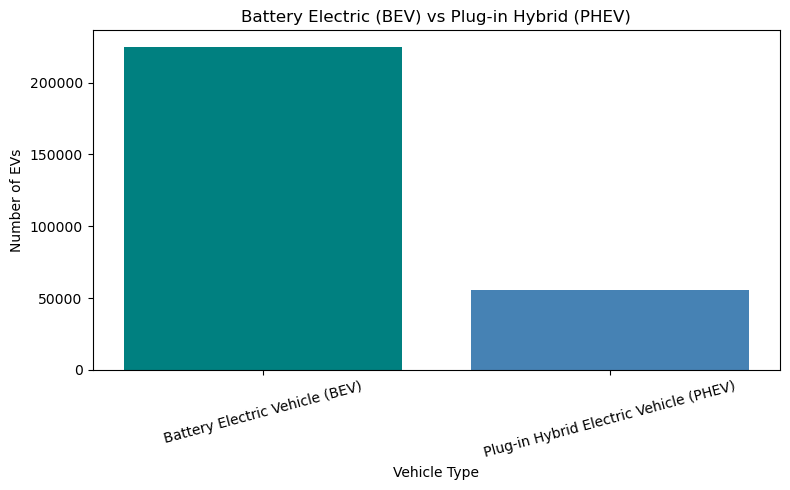

EV types chart saved!
Battery Electric Vehicle (BEV): 225,114 (80.2%)
Plug-in Hybrid Electric Vehicle (PHEV): 55,707 (19.8%)


In [15]:
plt.figure(figsize=(8, 5))

ev_types = df_clean['Electric Vehicle Type'].value_counts()

plt.bar(ev_types.index, ev_types.values, color=['teal', 'steelblue'])
plt.title('Battery Electric (BEV) vs Plug-in Hybrid (PHEV)')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of EVs')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('ev_types.png')
plt.show()

print("EV types chart saved!")
for vtype, count in ev_types.items():
    pct = count / len(df_clean) * 100
    print(f"{vtype}: {count:,} ({pct:.1f}%)")

In [16]:
import requests
import pandas as pd

url = "https://developer.nrel.gov/api/alt-fuel-stations/v1.json?api_key=DEMO_KEY&state=WA&fuel_type=ELEC&limit=100"

response = requests.get(url)
data = response.json()

stations = data['fuel_stations']
stations_df = pd.DataFrame(stations)

print("Total charging stations fetched:", len(stations_df))
print("\nSample stations:")
stations_df[['station_name', 'city', 'state', 'ev_level2_evse_num', 'ev_dc_fast_num']].head(5)

Total charging stations fetched: 100

Sample stations:


,station_name,city,state,ev_level2_evse_num,ev_dc_fast_num
0,Seattle-Tacoma International Airport - General...,Seattle,WA,68.0,NaN
1,Avista Corp,Spokane,WA,2.0,NaN
2,Steam Plant Parking,Spokane,WA,6.0,NaN
3,BELLEVUE BELLEVUE CH 1,Bellevue,WA,2.0,NaN
4,KING COUNTY DES ISSAQUAH P&R 2,Issaquah,WA,2.0,NaN


In [17]:
# Clean and prepare charging stations data for dashboard
stations_clean = stations_df[['station_name', 'city', 'state', 'ev_level2_evse_num', 'ev_dc_fast_num']].copy()
stations_clean['ev_level2_evse_num'] = stations_clean['ev_level2_evse_num'].fillna(0).astype(int)
stations_clean['ev_dc_fast_num'] = stations_clean['ev_dc_fast_num'].fillna(0).astype(int)
stations_clean['total_chargers'] = stations_clean['ev_level2_evse_num'] + stations_clean['ev_dc_fast_num']

print("Stations cleaned!")
print("\nTop 5 stations by total chargers:")
print(stations_clean.nlargest(5, 'total_chargers')[['station_name', 'city', 'total_chargers']])

# Save for dashboard
stations_clean.to_csv('charging_stations.csv', index=False)
print("\nSaved to 'charging_stations.csv'!")


Stations cleaned!

Top 5 stations by total chargers:
                                         station_name      city  \
0   Seattle-Tacoma International Airport - General...   Seattle   
32                       City of Seattle - Muni Tower   Seattle   
33     City of Seattle - Parking Enforcement Division   Seattle   
76                                  Snoqualmie Casino  Issaquah   
2                                 Steam Plant Parking   Spokane   

    total_chargers  
0               68  
32              32  
33              13  
76               8  
2                6  

Saved to 'charging_stations.csv'!
